# Initialize

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import scale

# Load Data

In [2]:
dfRet = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data/retail/retail_transactions.csv', encoding='iso-8859-1')
dfRet.tail(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541889,581585,22466,FAIRY TALE COTTAGE NIGHT LIGHT,12,12/9/2011 12:31,1.95,15804.0,United Kingdom
541890,581586,22061,LARGE CAKE STAND HANGING STRAWBERY,8,12/9/2011 12:49,2.95,13113.0,United Kingdom
541891,581586,23275,SET OF 3 HANGING OWLS OLLIE BEAK,24,12/9/2011 12:49,1.25,13113.0,United Kingdom
541892,581586,21217,RED RETROSPOT ROUND CAKE TINS,24,12/9/2011 12:49,8.95,13113.0,United Kingdom
541893,581586,20685,DOORMAT RED RETROSPOT,10,12/9/2011 12:49,7.08,13113.0,United Kingdom
541894,581587,22631,CIRCUS PARADE LUNCH BOX,12,12/9/2011 12:50,1.95,12680.0,France
541895,581587,22556,PLASTERS IN TIN CIRCUS PARADE,12,12/9/2011 12:50,1.65,12680.0,France
541896,581587,22555,PLASTERS IN TIN STRONGMAN,12,12/9/2011 12:50,1.65,12680.0,France
541897,581587,22728,ALARM CLOCK BAKELIKE PINK,4,12/9/2011 12:50,3.75,12680.0,France
541898,581587,22727,ALARM CLOCK BAKELIKE RED,4,12/9/2011 12:50,3.75,12680.0,France


# Prepare Data

In [3]:
dfRet['item_total'] = dfRet['UnitPrice'] * dfRet['Quantity']
dfRet.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,item_total
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34


In [4]:
dfRtc = dfRet.groupby('CustomerID').agg({'InvoiceNo': 'nunique', 'item_total': 'sum'})
dfRtc.rename(columns={'InvoiceNo': 'invoice_count', 'item_total': 'amt_total'}, inplace=True)
dfRtc.head()

,invoice_count,amt_total
CustomerID,,
12346.0,2,0.00
12347.0,7,4310.00
12348.0,4,1797.24
12349.0,1,1757.55
12350.0,1,334.40


In [5]:
X = scale(dfRtc[['invoice_count', 'amt_total']])

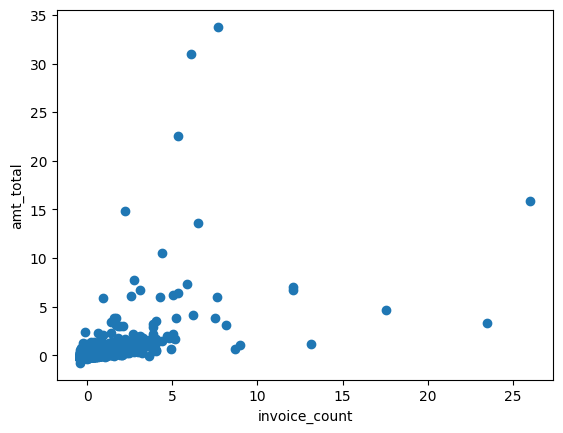

In [6]:
# Visualize scatterplot

plt.scatter(X[:,0], X[:,1])
plt.xlabel('invoice_count')
plt.ylabel('amt_total')
plt.show()

## Build K-Means Clustering Model

In [7]:
from sklearn.cluster import KMeans

# Define
mdlKmcRtc = KMeans(n_clusters=2, random_state=1)

# Fit
mdlKmcRtc.fit(X)

kmeans_labels = mdlKmcRtc.labels_

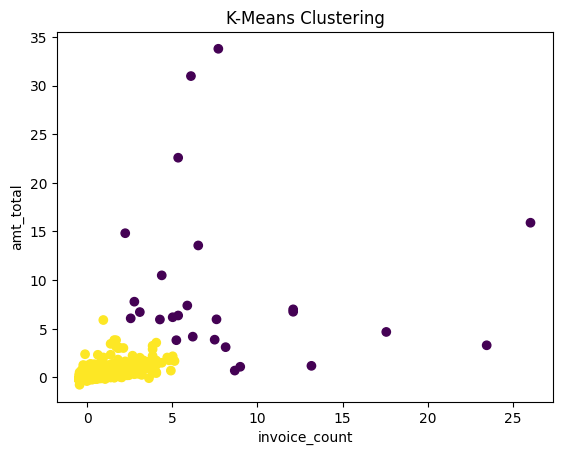

In [8]:
# Visualize K-Means

plt.scatter(X[:,0], X[:,1],c=kmeans_labels)
plt.xlabel('invoice_count')
plt.ylabel('amt_total')
plt.title('K-Means Clustering')
plt.show()

In [9]:
# Evaluate using silhouette score

from sklearn.metrics import silhouette_score

silhouette_score(X, kmeans_labels)


0.9503432954038323

In [10]:
# Function for K-Means Clustering

def cluster_kMeans(X,k):
  mdlKmcRtc = KMeans(n_clusters=k, random_state=1)
  mdlKmcRtc.fit(X)
  kmeans_labels = mdlKmcRtc.labels_
  kmeans_sil_score = silhouette_score(X, kmeans_labels)
  return kmeans_labels, kmeans_sil_score

In [11]:
for k in [2,3,4,5,6]:
  kmeans_labels_k, kmeans_sil_score_k = cluster_kMeans(X,k)
  print('k:',k, '\t\t','sil_score:',kmeans_sil_score_k)

k: 2 		 sil_score: 0.9503432954038323
k: 3 		 sil_score: 0.8229586806895549
k: 4 		 sil_score: 0.7675493870106322
k: 5 		 sil_score: 0.7514378910638715
k: 6 		 sil_score: 0.7299224375528661


## Build Hierarchical Clustering

In [12]:
from scipy.cluster import hierarchy
Z = hierarchy.linkage(X,'ward')

Text(0, 0.5, 'Distance')

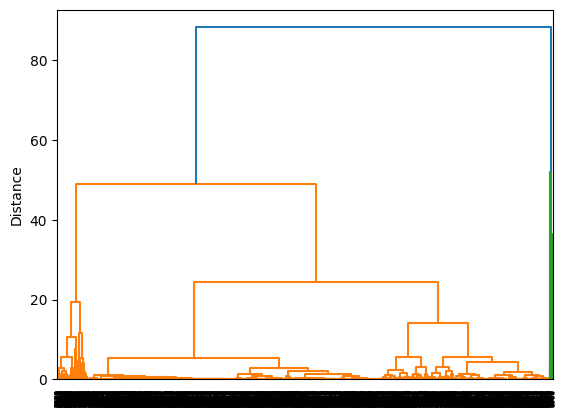

In [14]:
hierarchy.dendrogram(Z)
plt.ylabel('Distance')

In [21]:
from sklearn.cluster import AgglomerativeClustering

# Define
mdlHrcRtc = AgglomerativeClustering()

# Fit
mdlHrcRtc.fit(X)

hclust_labels = mdlHrcRtc.labels_

silhouette_score(X, hclust_labels)

0.9509264436578768

In [18]:
set(hclust_labels)

{0, 1}

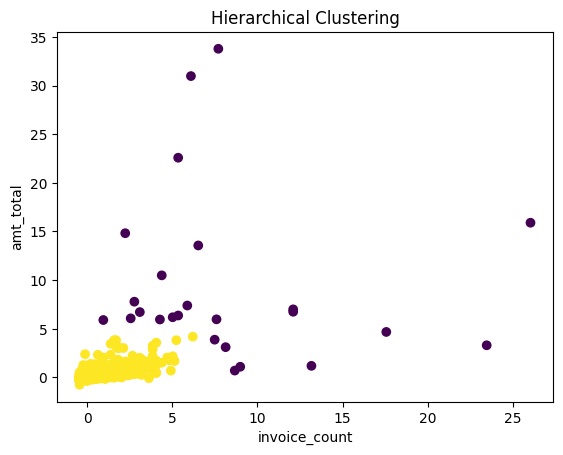

In [22]:
# Visualize Hierarchical Clustering

plt.scatter(X[:,0], X[:,1],c=hclust_labels)
plt.xlabel('invoice_count')
plt.ylabel('amt_total')
plt.title('Hierarchical Clustering')
plt.show()

## Build DBSCAN Model

In [34]:
from sklearn.cluster import DBSCAN

# Define
mdlDbsRtc = DBSCAN(eps=1)

# Fit
mdlDbsRtc.fit(X)

dbscan_labels = mdlDbsRtc.labels_

silhouette_score(X, dbscan_labels)

0.9472191707848616

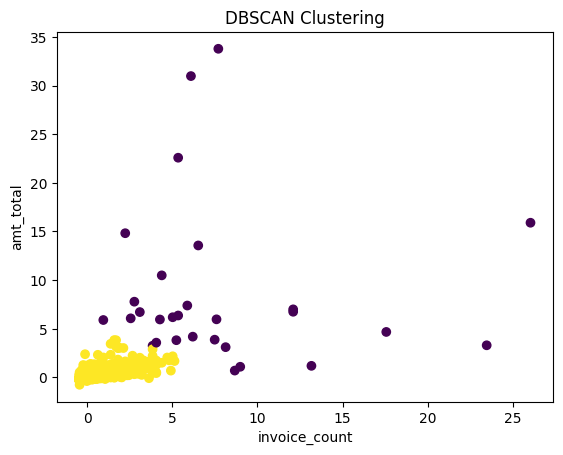

In [35]:
# Visualize Hierarchical Clustering

plt.scatter(X[:,0], X[:,1],c=dbscan_labels)
plt.xlabel('invoice_count')
plt.ylabel('amt_total')
plt.title('DBSCAN Clustering')
plt.show()

In [36]:
set(dbscan_labels)

{-1, 0}

In [37]:
# Function for DBSCAN

def cluster_DBScan(X,e):
  mdlDbsRtc = DBSCAN(eps=e)
  mdlDbsRtc.fit(X)
  dbscan_labels_e = mdlDbsRtc.labels_
  dbscan_sil_score_e = silhouette_score(X, dbscan_labels)
  dbscan_clusters_e = len(set(dbscan_labels))-(1 if -1 in dbscan_labels else 0)
  dbscan_anomalies_e = len(dbscan_labels[dbscan_labels==-1])
  return dbscan_labels_e, dbscan_sil_score_e, dbscan_clusters_e, dbscan_anomalies_e

In [40]:
for e in [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0,1.5,2.0,2.5,3.0,4.0,5.0,6.0,7.0,8.0,9.0]:
  dbscan_labels_e, dbscan_sil_score_e, dbscan_clusters_e, dbscan_anomalies_e = cluster_DBScan(X,e)
  print('eps:',e, '\t\t','sil_score:',dbscan_sil_score_e, '\t\t','clusters:',dbscan_clusters_e, '\t\t','anomalies:',dbscan_anomalies_e)


eps: 0.1 		 sil_score: 0.44303062146907807 		 clusters: 24 		 anomalies: 235
eps: 0.2 		 sil_score: 0.8835745228080347 		 clusters: 1 		 anomalies: 110
eps: 0.3 		 sil_score: 0.9082453438451032 		 clusters: 1 		 anomalies: 75
eps: 0.4 		 sil_score: 0.8723010302239043 		 clusters: 2 		 anomalies: 60
eps: 0.5 		 sil_score: 0.8277387470113158 		 clusters: 3 		 anomalies: 43
eps: 0.6 		 sil_score: 0.8260463106415202 		 clusters: 3 		 anomalies: 34
eps: 0.7 		 sil_score: 0.8336443702741331 		 clusters: 2 		 anomalies: 32
eps: 0.8 		 sil_score: 0.9460932490176458 		 clusters: 1 		 anomalies: 30
eps: 0.9 		 sil_score: 0.9472191707848616 		 clusters: 1 		 anomalies: 29
eps: 1.0 		 sil_score: 0.9472191707848616 		 clusters: 1 		 anomalies: 29
eps: 1.5 		 sil_score: 0.9502179515979182 		 clusters: 1 		 anomalies: 26
eps: 2.0 		 sil_score: 0.9129211142544389 		 clusters: 2 		 anomalies: 17
eps: 2.5 		 sil_score: 0.9651633796425144 		 clusters: 1 		 anomalies: 12
eps: 3.0 		 sil_score: 0.965163379